In [1]:
# INSTALL AND IMPORTS
!pip install -q torchvision kagglehub

import kagglehub
import os
import random
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import torch
import torch.nn as nn



In [2]:
# DOWNLOAD DATASET AND SET PATHS
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

dataset_path = ".." + path + "/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"
train_path = os.path.join(dataset_path, "train")
val_path = os.path.join(dataset_path, "valid")

print("Train path exists:", os.path.exists(train_path))
print("Validation path exists:", os.path.exists(val_path))


Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Train path exists: True
Validation path exists: True


In [3]:
# DISPLAY A RANDOM IMAGE
classes = [name for name in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, name))]
class_name = random.choice(classes)
class_path = os.path.join(train_path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

img = Image.open(img_path)
print("Class:", class_name)
print("Width:", img.width, "Height:", img.height)
img.show()


Class: Grape___Esca_(Black_Measles)
Width: 256 Height: 256


100%|██████████| 4394/4394 [08:48<00:00,  8.31it/s]Dataset Mean: [0.4759633541107178, 0.5003823041915894, 0.42664191126823425]
Dataset Std: [0.2102811634540558, 0.18884509801864624, 0.22626712918281555]


In [4]:
# # COMPUTE DATASET MEAN AND STD
# This section has being commented, beacuse it take too much time and I have taken its values in the raw form down there:

# device = "cuda" if torch.cuda.is_available() else "cpu"

# def compute_mean_std(dataset, batch_size=16, num_workers=0):
#     loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
#     channel_sum = torch.zeros(3, device=device)
#     channel_sqsum = torch.zeros(3, device=device)
#     pixel_count = 0

#     for x, _ in tqdm(loader):
#         x = x.to(device)
#         b, c, h, w = x.shape
#         pixel_count += h * w * b
#         channel_sum += x.sum(dim=[0, 2, 3])
#         channel_sqsum += (x**2).sum(dim=[0, 2, 3])

#     mean = channel_sum / pixel_count
#     std = torch.sqrt(channel_sqsum / pixel_count - mean ** 2)
#     return mean.tolist(), std.tolist()

# dummy_transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor()
# ])

# tmp_dataset = datasets.ImageFolder(root=train_path, transform=dummy_transform)
# mean, std = compute_mean_std(tmp_dataset)
# print("Dataset Mean:", mean)
# print("Dataset Std:", std)


In [5]:
# DATA TRANSFORMATIONS
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4759633541107178, 0.5003823041915894, 0.42664191126823425],
                         std=[0.2102811634540558, 0.18884509801864624, 0.22626712918281555])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
     transforms.Normalize(mean=[0.4759633541107178, 0.5003823041915894, 0.42664191126823425],
                         std=[0.2102811634540558, 0.18884509801864624, 0.22626712918281555])
])


In [6]:
# CREATE DATASETS AND DATALOADERS
train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)
valid_dataset = datasets.ImageFolder(root=val_path, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=0)

print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(valid_loader))


Number of training batches: 2197
Number of validation batches: 550


In [7]:
# # SIMPLE CNN MODEL ( just for teaching the basic )
# class SimpleCNN(nn.Module):
#     def __init__(self, in_features, out_features, hidden_units):
#         super().__init__()
#         self.layer = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(in_features=in_features, out_features=hidden_units),
#             nn.ReLU(),
#             nn.Linear(in_features=hidden_units, out_features=out_features)
#         )

#     def forward(self, x):
#         return self.layer(x)

# simpleCNN = SimpleCNN(3*224*224, 38, 256).to(device)



import torch
import torch.nn as nn
import torch.optim as optim

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=38):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )


        # This layer ensures the output of the conv blocks is always 7x7
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            # Now the input size is always predictable: 64 channels * 7 * 7
            nn.Linear(64 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5), # Adding dropout is good practice for FC layers
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.adaptive_pool(x) # Apply the adaptive pooling
        x = self.fc_layers(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=38).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Example of running the model with a different input size
dummy_input = torch.randn(2, 3, 256, 256).to(device) # Not 224x224
output = model(dummy_input)
print(f"Model output shape: {output.shape}") # Will correctly output (2, 38)

Model output shape: torch.Size([2, 38])


In [8]:
# # LOSS FUNCTION AND OPTIMIZER
# loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(simpleCNN.parameters(), lr=0.01, momentum=0.9)


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Set seed for reproducibility
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training parameters
epochs = 5  # You can increase this later
batch_size = 32

# Use the already defined DataLoaders:
# train_loader, valid_loader

for epoch in range(epochs):
    train_loss = 0
    train_correct = 0
    valid_loss = 0
    valid_correct = 0

    # -------- Training Loop --------
    model.train()
    for x, y in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = y_pred.argmax(dim=1)
        train_correct += (preds == y).sum().item()

    # -------- Validation Loop --------
    model.eval()
    with torch.inference_mode():
        for x_val, y_val in valid_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            y_pred_val = model(x_val)
            loss = loss_fn(y_pred_val, y_val)
            valid_loss += loss.item()

            preds_val = y_pred_val.argmax(dim=1)
            valid_correct += (preds_val == y_val).sum().item()

    # -------- Metrics --------
    train_accuracy = train_correct / len(train_loader.dataset)
    valid_accuracy = valid_correct / len(valid_loader.dataset)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss/len(train_loader):.4f}, Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {valid_loss/len(valid_loader):.4f}, Val Acc: {valid_accuracy:.4f}"
    )


Training Epoch 1: 100%|██████████| 2197/2197 [08:33<00:00,  4.28it/s]


Epoch 1 | Train Loss: 1.2227, Train Acc: 0.6318 | Val Loss: 0.4188, Val Acc: 0.8719


Training Epoch 2: 100%|██████████| 2197/2197 [05:00<00:00,  7.31it/s]


Epoch 2 | Train Loss: 0.5683, Train Acc: 0.8204 | Val Loss: 0.2602, Val Acc: 0.9177


Training Epoch 3: 100%|██████████| 2197/2197 [05:00<00:00,  7.32it/s]


Epoch 3 | Train Loss: 0.4209, Train Acc: 0.8668 | Val Loss: 0.1930, Val Acc: 0.9371


Training Epoch 4: 100%|██████████| 2197/2197 [05:06<00:00,  7.18it/s]


Epoch 4 | Train Loss: 0.3466, Train Acc: 0.8904 | Val Loss: 0.2135, Val Acc: 0.9284


Training Epoch 5: 100%|██████████| 2197/2197 [04:59<00:00,  7.35it/s]


Epoch 5 | Train Loss: 0.3008, Train Acc: 0.9027 | Val Loss: 0.1489, Val Acc: 0.9504


In [10]:
# # Step 1: Save the trained model
# Save the model
torch.save(model.state_dict(), "plant_disease_cnn.pth")
print("Model saved as plant_disease_cnn.pth")


Model saved as plant_disease_cnn.pth


In [11]:
#  Step 2: Load the model

# Recreate the model architecture
loaded_model = SimpleCNN(num_classes=38).to(device)

# Load the trained weights
loaded_model.load_state_dict(torch.load("plant_disease_cnn.pth", map_location=device))
loaded_model.eval()

print("Model loaded and ready for inference")

Model loaded and ready for inference


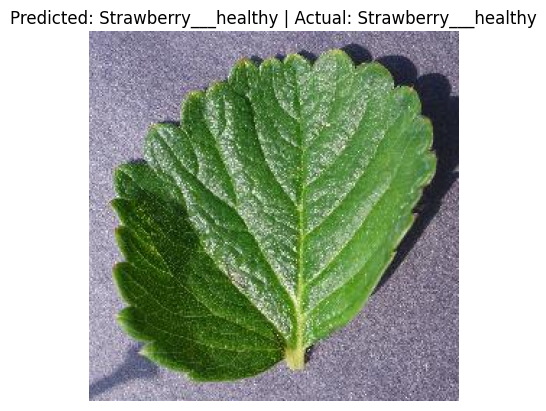

In [12]:
# Step 3: Make a prediction on one image

from torchvision import transforms
import matplotlib.pyplot as plt

# Pick a random validation image
class_name = random.choice(os.listdir(val_path))
class_path = os.path.join(val_path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

# Open image
img = Image.open(img_path).convert("RGB")

# Apply same transform as validation set
input_tensor = test_transform(img).unsqueeze(0).to(device)

# Run through model
with torch.inference_mode():
    pred = loaded_model(input_tensor)
    predicted_class = pred.argmax(dim=1).item()

# Get class labels from dataset
idx_to_class = {v: k for k, v in valid_dataset.class_to_idx.items()}
predicted_label = idx_to_class[predicted_class]

# Show image + prediction
plt.imshow(img)
plt.title(f"Predicted: {predicted_label} | Actual: {class_name}")
plt.axis("off")
plt.show()




In [13]:
from google.colab import files
files.download("plant_disease_cnn.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# LOAD MODEL BACK
loaded_model = SimpleCNN(num_classes=38).to(device)
loaded_model.load_state_dict(torch.load("plant_disease_cnn.pth", map_location=device))
loaded_model.eval()
print("Model loaded and ready for inference")


Model loaded and ready for inference


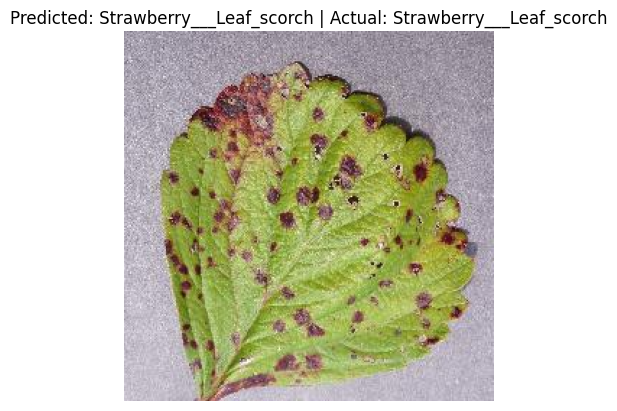

In [15]:
# MAKE A PREDICTION ON A RANDOM IMAGE
class_name = random.choice(os.listdir(val_path))
class_path = os.path.join(val_path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

img = Image.open(img_path).convert("RGB")
input_tensor = test_transform(img).unsqueeze(0).to(device)

with torch.inference_mode():
    pred = loaded_model(input_tensor)
    predicted_class = pred.argmax(dim=1).item()

idx_to_class = {v: k for k, v in valid_dataset.class_to_idx.items()}
predicted_label = idx_to_class[predicted_class]

plt.imshow(img)
plt.title(f"Predicted: {predicted_label} | Actual: {class_name}")
plt.axis("off")
plt.show()
